In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/wfp_food_prices_nga.csv", skiprows=[1])

df["date"] = pd.to_datetime(df["date"])
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df = df.dropna(subset=["price"])

print("Shape:", df.shape)
df.head()

Shape: (51106, 14)


,date,admin1,admin2,market,latitude,longitude,category,commodity,unit,priceflag,pricetype,currency,price,usdprice
0,2002-01-15,Katsina,Jibia,Jibia (CBM),13.08,7.24,cereals and tubers,Maize,KG,actual,Wholesale,NGN,175.92,1.5525
1,2002-01-15,Katsina,Jibia,Jibia (CBM),13.08,7.24,cereals and tubers,Millet,KG,actual,Wholesale,NGN,150.18,1.3254
2,2002-01-15,Katsina,Jibia,Jibia (CBM),13.08,7.24,cereals and tubers,Rice (imported),KG,actual,Wholesale,NGN,358.70,3.1656
3,2002-01-15,Katsina,Jibia,Jibia (CBM),13.08,7.24,cereals and tubers,Sorghum,KG,actual,Wholesale,NGN,155.61,1.3733
4,2002-01-15,Katsina,Jibia,Jibia (CBM),13.08,7.24,pulses and nuts,Beans (niebe),KG,actual,Wholesale,NGN,196.87,1.7374


In [ ]:
print("Commodities:", df["commodity"].nunique())
print("States (admin1):", df["admin1"].nunique())
print("Markets:", df["market"].nunique())
print("Date range:", df["date"].min(), "to", df["date"].max())
print()
print(df["category"].value_counts())

Commodities: 42
States (admin1): 14
Markets: 55
Date range: 2002-01-15 00:00:00 to 2023-11-15 00:00:00

category
cereals and tubers       24938
pulses and nuts           8651
vegetables and fruits     5504
meat, fish and eggs       3967
oil and fats              3232
miscellaneous food        1900
non-food                  1890
milk and dairy            1024
Name: count, dtype: int64


In [ ]:
check = df[(df["commodity"] == "Maize (white)") & (df["market"] == "Ibadab")]
print(check.groupby(["unit", "pricetype"]).size())

Series([], dtype: int64)


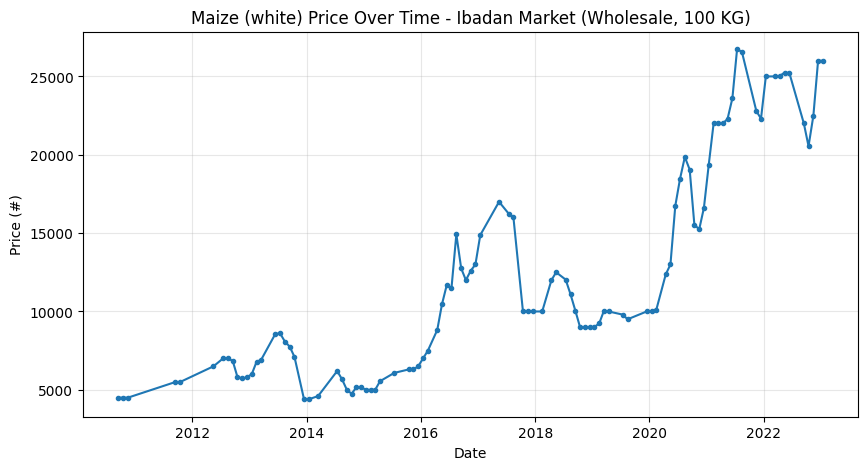

In [ ]:
commodity = "Maize (white)"
market = "Ibadan"
unit = "100 KG" #wholesale - has the most consistent, continous data
subset = df[(df["commodity"] == commodity) & (df["market"] == market) & (df["unit"] == unit)]
subset = subset.sort_values("date")

plt.figure(figsize=(10, 5))
plt.plot(subset["date"], subset["price"], marker="o", markersize=3)
plt.title(f"{commodity} Price Over Time - {market} Market (Wholesale, {unit})")
plt.xlabel("Date")
plt.ylabel("Price (#)")
plt.grid(alpha=0.3)
plt.show()

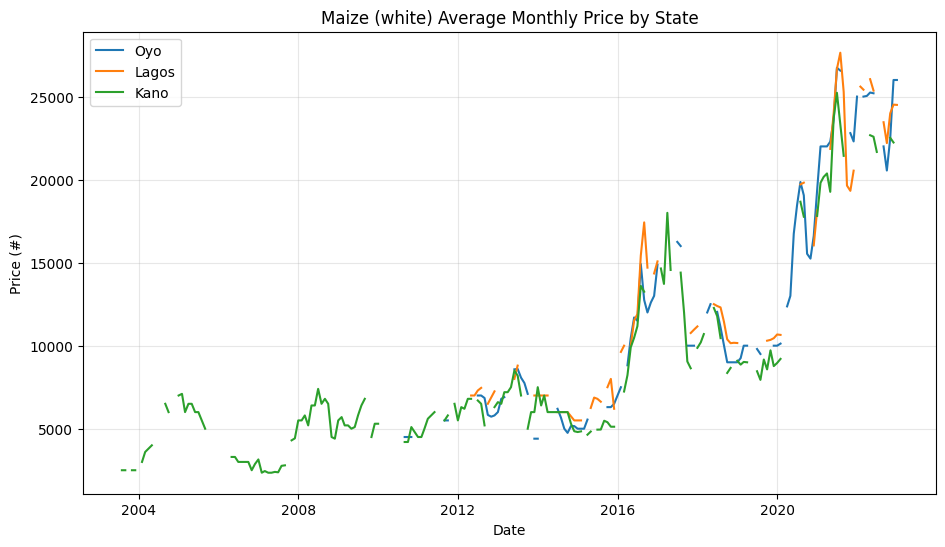

In [19]:
#compare price trends across states

states = ["Oyo", "Lagos", "Kano"]
plt.figure(figsize=(11, 6))
for state in states:
  state_date = df[(df["commodity"] == commodity) & (df["unit"] == unit) & (df["admin1"] == state)]
  monthly_avg = state_date.groupby(pd.Grouper(key="date", freq="MS"))["price"].mean()
  plt.plot(monthly_avg.index, monthly_avg.values, label=state)

  plt.title(f"{commodity} Average Monthly Price by State")
  plt.xlabel("Date")
  plt.ylabel("Price (#)")
  plt.legend()
  plt.grid(alpha=0.3)
plt.show()


In [20]:
pivot = df[(df["commodity"] == commodity) & (df["unit"] == unit) & (df["admin1"].isin(states))]
pivot_table = pivot.pivot_table(index=pd.Grouper(key="date", freq="MS"), columns="admin1", values="price", aggfunc="mean")

correlation = pivot_table.corr().round(2)
print(correlation)

admin1  Kano  Lagos   Oyo
admin1                   
Kano    1.00   0.99  0.99
Lagos   0.99   1.00  0.99
Oyo     0.99   0.99  1.00


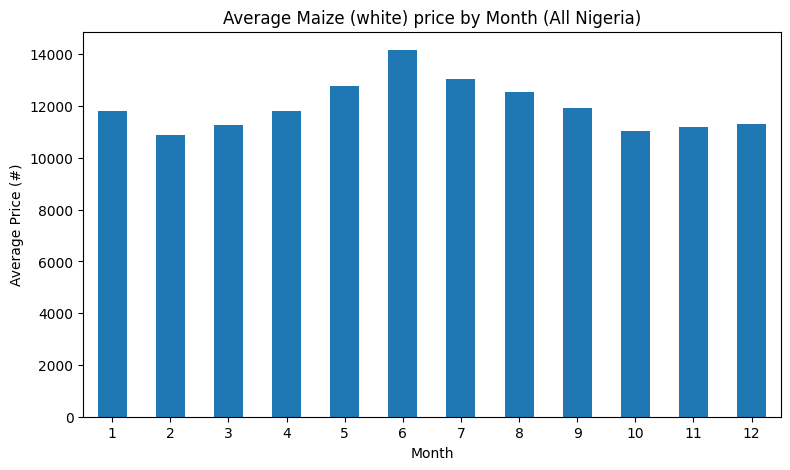

month
1     11815.0
2     10869.0
3     11285.0
4     11808.0
5     12789.0
6     14166.0
7     13032.0
8     12559.0
9     11916.0
10    11057.0
11    11208.0
12    11300.0
Name: price, dtype: float64


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/wfp_food_prices_nga.csv", skiprows=[1])
df["date"] = pd.to_datetime(df["date"])
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df = df.dropna(subset=["price"])

commodity = "Maize (white)"
unit = "100 KG" #wholesale - has the most consistent, continous data

season_data = df[(df["commodity"] == commodity) & (df["unit"] == unit)].copy()
season_data["month"] = season_data["date"].dt.month

monthly_avg = season_data.groupby("month")["price"].mean()
plt.figure(figsize=(9, 5))
monthly_avg.plot(kind="bar")
plt.title(f"Average {commodity} price by Month (All Nigeria)")
plt.xlabel("Month")
plt.ylabel(("Average Price (#)"))
plt.xticks(rotation=0)
plt.show()
print(monthly_avg.round(0))

# New Section